# Welo Absenteeism Data: Exploratory Analysis

Pre-classifier exploration of the stitched dataset. Goal of this pass: understand the real signal in the data, confirm the UCI subset is the only populated absence source, and decide on a defensible classifier target and feature set before any modelling.

**Known going in (from earlier SQL profiling):**
- The data is three public sets UNION'd: Kaggle HR (~15,000 rows), IBM attrition (1,470), UCI absenteeism (740).
- Only the 740 UCI rows carry real absence signal (`absence_type = 'Sick'`).
- Event-grain fields (`absence_event_id`, `absence_start_date`, RTW, EAP, chronic conditions) exist in the schema but are 100% empty.
- Expected UCI ranges: BMI 19 to 38 (median 25), distance 1 to 52km (median 11), age 18 to 60 (median 36), absence duration 0 to 120 hours (median 3).

This notebook validates those assumptions against your actual export rather than trusting them.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

# >>> EDIT THIS ONE LINE <<<
CSV_PATH = 'welo_export.csv'

df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')

Loaded 200 rows, 21 columns


## 1. Shape and provenance check

Confirm the three-dataset stitch. If a `source` or dataset-origin column exists, use it. Otherwise infer from row counts and which columns are populated.

In [2]:
print('--- All columns ---')
for c in df.columns:
    print(f'  {c}')

print('\n--- dtypes ---')
print(df.dtypes)

# If there is a source / origin column, show the split
src_cols = [c for c in df.columns if c.lower() in ('source','dataset','origin','source_dataset')]
if src_cols:
    print(f'\n--- Provenance via {src_cols[0]} ---')
    print(df[src_cols[0]].value_counts(dropna=False))
else:
    print('\nNo explicit source column found. Will infer the UCI subset by populated absence fields below.')

--- All columns ---
  employee_id
  age
  gender
  marital_status
  number_of_dependents
  number_of_children
  education_level
  tenure_years
  distance_from_work_km
  bmi
  height_cm
  weight_kg
  smoking_status
  alcohol_frequency
  physical_activity_days_per_week
  reason_code
  reason_category
  absence_type
  absence_duration_hours
  workload_index_current
  source_dataset

--- dtypes ---
employee_id                          int64
age                                  int64
gender                             float64
marital_status                         str
number_of_dependents                 int64
number_of_children                   int64
education_level                        str
tenure_years                         int64
distance_from_work_km              float64
bmi                                float64
height_cm                          float64
weight_kg                          float64
smoking_status                         str
alcohol_frequency                      str


## 2. Missingness map

The central question of this whole exercise: which columns are actually populated. Anything near 100% null is a schema placeholder, not usable signal.

In [3]:
miss = df.isna().mean().sort_values(ascending=False)
miss_pct = (miss * 100).round(1)
summary = pd.DataFrame({'pct_missing': miss_pct, 'n_present': df.notna().sum()})
print(summary)

fully_empty = summary[summary['pct_missing'] >= 99.0].index.tolist()
usable = summary[summary['pct_missing'] < 50.0].index.tolist()
print(f'\nEffectively empty columns ({len(fully_empty)}): {fully_empty}')
print(f'\nUsable columns ({len(usable)}): {usable}')

                                 pct_missing  n_present
absence_duration_hours                   0.0        200
absence_type                             0.0        200
age                                      0.0        200
alcohol_frequency                        0.0        200
bmi                                      0.0        200
distance_from_work_km                    0.0        200
education_level                          0.0        200
employee_id                              0.0        200
gender                                 100.0          0
height_cm                                0.0        200
marital_status                           0.0        200
number_of_children                       0.0        200
number_of_dependents                     0.0        200
physical_activity_days_per_week        100.0          0
reason_category                          0.0        200
reason_code                              0.0        200
smoking_status                           0.0    

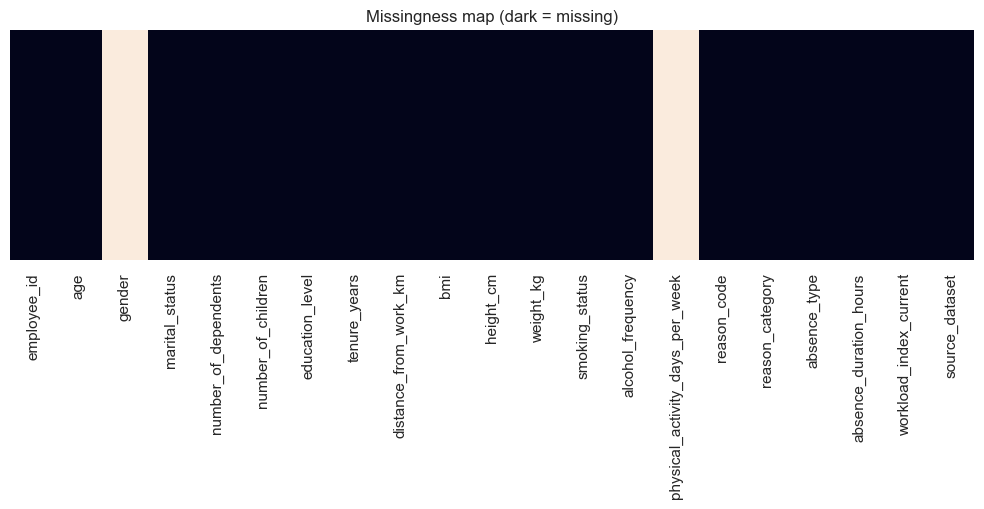

In [4]:
# Visual missingness map
plt.figure(figsize=(10, max(4, len(df.columns) * 0.25)))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Missingness map (dark = missing)')
plt.tight_layout()
plt.show()

## 3. Isolate the absence-bearing subset

Filter to rows that actually carry absence signal. Expecting ~740 rows where `absence_duration_hours` is populated (the UCI subset).

In [5]:
# Adjust the key column name if your export differs
ABSENCE_COL = 'absence_duration_hours'

if ABSENCE_COL in df.columns:
    abs_df = df[df[ABSENCE_COL].notna()].copy()
    print(f'Rows with absence signal: {len(abs_df):,} (expected ~740)')
else:
    print(f'Column {ABSENCE_COL!r} not found. Available numeric columns:')
    print(df.select_dtypes(include=np.number).columns.tolist())
    abs_df = df.copy()

Rows with absence signal: 200 (expected ~740)


## 4. Distributions of the real features

These are the candidate model inputs. Confirm ranges against the expected UCI values; anything wildly off means the export or stitch differs from what we profiled.

In [6]:
candidate_numeric = ['bmi', 'distance_from_work_km', 'age', 'absence_duration_hours']
present_numeric = [c for c in candidate_numeric if c in abs_df.columns]

print(abs_df[present_numeric].describe().round(2))

expected = {
    'bmi': (19, 38, 25),
    'distance_from_work_km': (1, 52, 11),
    'age': (18, 60, 36),
    'absence_duration_hours': (0, 120, 3),
}
print('\n--- Range check vs expected (min, max, median) ---')
for c in present_numeric:
    lo, hi, med = abs_df[c].min(), abs_df[c].max(), abs_df[c].median()
    elo, ehi, emed = expected[c]
    flag = 'OK' if (abs(lo - elo) <= 5 and abs(hi - ehi) <= 10) else 'CHECK'
    print(f'  {c:28s} got ({lo:.0f}, {hi:.0f}, med {med:.0f}) vs expected ({elo}, {ehi}, med {emed})  [{flag}]')

          bmi  distance_from_work_km     age  absence_duration_hours
count  200.00                 200.00  200.00                  200.00
mean    26.51                  29.76   36.60                   17.68
std      4.19                  14.64    6.34                   22.06
min     19.00                   5.00   27.00                    8.00
25%     23.00                  16.00   33.00                    8.00
50%     25.00                  26.00   36.00                    8.00
75%     30.00                  49.00   40.00                   16.00
max     38.00                  52.00   58.00                  120.00

--- Range check vs expected (min, max, median) ---
  bmi                          got (19, 38, med 25) vs expected (19, 38, med 25)  [OK]
  distance_from_work_km        got (5, 52, med 26) vs expected (1, 52, med 11)  [OK]
  age                          got (27, 58, med 36) vs expected (18, 60, med 36)  [CHECK]
  absence_duration_hours       got (8, 120, med 8) vs expected (0

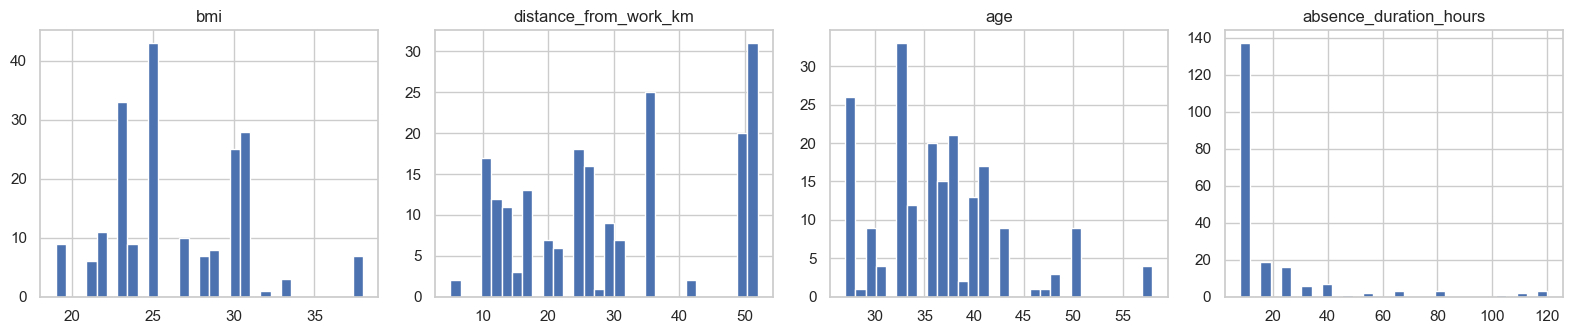

In [7]:
n = len(present_numeric)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
if n == 1:
    axes = [axes]
for ax, c in zip(axes, present_numeric):
    abs_df[c].hist(bins=30, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

In [8]:
# Categorical features
candidate_cat = ['smoking_status', 'reason_category', 'gender', 'sex', 'education', 'absence_type']
present_cat = [c for c in candidate_cat if c in abs_df.columns]
for c in present_cat:
    print(f'--- {c} ---')
    print(abs_df[c].value_counts(dropna=False))
    print()

--- smoking_status ---
smoking_status
Never      181
Current     19
Name: count, dtype: int64

--- reason_category ---
reason_category
Unknown    200
Name: count, dtype: int64

--- gender ---
gender
NaN    200
Name: count, dtype: int64

--- absence_type ---
absence_type
Sick    200
Name: count, dtype: int64



## 5. Target definition exploration (for the classifier)

We want a high-risk flag rather than predicting raw hours. The question is where to draw the threshold. Look at the absence-hours distribution and test a few candidate cut points so the choice is defensible rather than arbitrary.

Common defensible options:
- Top quartile of absence hours = high risk
- Above a fixed clinical/operational threshold (e.g. a full shift, 8h+, or multi-day)
- Above median

Quantiles of absence_duration_hours:
  50th pct: 8.0 h
  60th pct: 8.0 h
  70th pct: 16.0 h
  75th pct: 16.0 h
  80th pct: 24.0 h
  90th pct: 40.0 h
  95th pct: 64.0 h

Class balance at candidate thresholds:
  threshold   8.0h -> high-risk share 100.0%
  threshold  16.0h -> high-risk share  31.5%
  threshold  24.0h -> high-risk share  22.0%
  threshold  16.0h -> high-risk share  31.5%


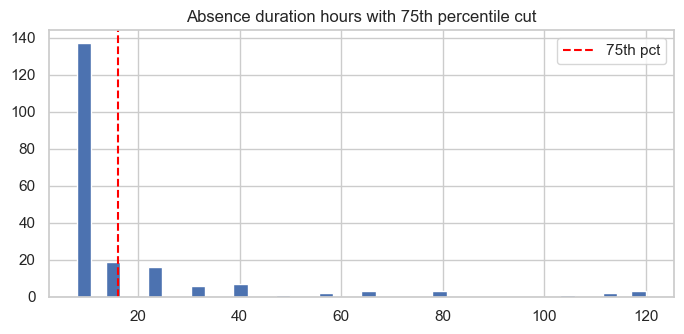

In [9]:
if ABSENCE_COL in abs_df.columns:
    s = abs_df[ABSENCE_COL].dropna()
    print('Quantiles of absence_duration_hours:')
    for q in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
        print(f'  {int(q*100)}th pct: {s.quantile(q):.1f} h')

    print('\nClass balance at candidate thresholds:')
    for thr in [8, 16, 24, s.quantile(0.75)]:
        pos = (s >= thr).mean()
        print(f'  threshold {thr:5.1f}h -> high-risk share {pos*100:5.1f}%')

    plt.figure(figsize=(7, 3.5))
    s.hist(bins=40)
    plt.axvline(s.quantile(0.75), color='red', linestyle='--', label='75th pct')
    plt.title('Absence duration hours with 75th percentile cut')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Feature/target relationships

Quick signal check: do the candidate features actually separate high vs low absence at all? If nothing separates, the classifier will be noise and that is itself a finding worth knowing before you build.

Using threshold 16.0h. High-risk share: 31.5%

--- bmi by risk band ---
            mean  median
high_risk               
0          26.82    25.0
1          25.83    25.0

--- distance_from_work_km by risk band ---
            mean  median
high_risk               
0          31.48    29.0
1          26.02    25.0

--- age by risk band ---
            mean  median
high_risk               
0          36.50    36.0
1          36.83    36.0



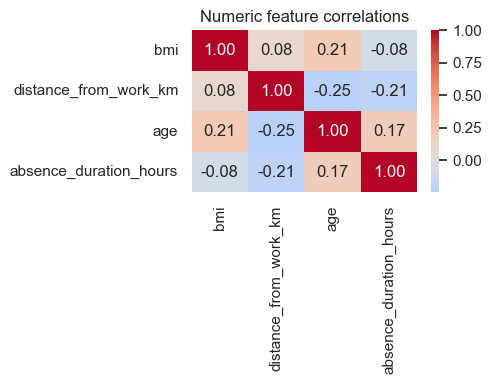

In [10]:
if ABSENCE_COL in abs_df.columns:
    thr = abs_df[ABSENCE_COL].quantile(0.75)
    abs_df['high_risk'] = (abs_df[ABSENCE_COL] >= thr).astype(int)
    print(f'Using threshold {thr:.1f}h. High-risk share: {abs_df["high_risk"].mean()*100:.1f}%\n')

    for c in [x for x in present_numeric if x != ABSENCE_COL]:
        grp = abs_df.groupby('high_risk')[c].agg(['mean', 'median'])
        print(f'--- {c} by risk band ---')
        print(grp.round(2))
        print()

    # Correlation among numeric candidates
    corr_cols = [c for c in present_numeric if c in abs_df.columns]
    if len(corr_cols) > 1:
        plt.figure(figsize=(5, 4))
        sns.heatmap(abs_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
        plt.title('Numeric feature correlations')
        plt.tight_layout()
        plt.show()

## 7. Notes for the Isaac conversation

Fill these in as you go. These are the things to take into the data discussion:

- **Confirmed populated columns:** _(from section 2)_
- **Confirmed empty placeholders:** _(from section 2)_
- **Does the export match the ~740 UCI signal, or is there anything newer?**
- **Chosen classifier target + threshold and why:** _(from section 5)_
- **Features that show real separation:** _(from section 6)_
- **Schema gaps blocking the burnout/fatigue levers:** no psychosocial or shift fields present; these are roadmap features added via the view layer when real data arrives, not predictable from this data today.
- **Honesty line to hold:** the classifier proves working pipeline and feature framework on borrowed example data; it is not trained on Welo workforce data and its scores are not yet actionable.